# Consistency check: MCEvidence, LHME (harmonic) vs. Nautilus

MCMC chains in `../nautilus/` use the same sampled parameters and priors as the Nautilus nested-sampling runs (DES likelihood), for two data combinations:

- **DD** (`sn.desdovekie`)
- **DD+BAO** (`sn.desdovekie + bao.desi_dr2`)

Sampled parameters:
- $\Lambda$CDM: `h`, `Omega_m`
- CPL: `h`, `Omega_m`, `w0_fld`, `wa_fld`

There are 8 MCMC chains per run, so we test harmonic with `block_num = 8, 16, 32` (no further splitting, 2x, 4x).

Nautilus reference values (paper):
- DD: $\ln\mathcal{Z}_{\Lambda\mathrm{CDM}} = -822.5$, $\ln\mathcal{Z}_{\mathrm{CPL}} = -823.4$
- DD+BAO: $\ln\mathcal{Z}_{\Lambda\mathrm{CDM}} = -833.2$, $\ln\mathcal{Z}_{\mathrm{CPL}} = -834.3$

In [1]:
from cosmctools import *
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams["figure.dpi"] = 300
mpl.rc("axes", labelsize=16)
mpl.rc("legend", fontsize=14)
mpl.rc("xtick", labelsize=12)
mpl.rc("ytick", labelsize=12)

In [2]:
def make_and_train(root, params, burnin, block_num, temp=0.8, nchains=8):
    m = cosmo_model(root, burnin=burnin, block_num=block_num, nchains=nchains)
    m.set_sampled_params(params)
    m.train_model(verbose=False)
    m.set_temp(temp=temp)
    return m


def to_lnZ(hm_res):
    """harmonic returns (-lnZ, (err_low_inv, err_up_inv)); convert to (lnZ, err_low, err_up)."""
    inv, err_inv = hm_res
    return -inv, abs(err_inv[1]), abs(err_inv[0])


# Nautilus reference values (paper)
NAUT_DD = {"lcdm": -822.5, "cpl": -823.4}
NAUT_DD["bf"] = NAUT_DD["cpl"] - NAUT_DD["lcdm"]

NAUT_DDBAO = {"lcdm": -833.2, "cpl": -834.3}
NAUT_DDBAO["bf"] = NAUT_DDBAO["cpl"] - NAUT_DDBAO["lcdm"]

block_nums = [8, 16, 32]
block_offsets = {8: -0.18, 16: 0.0, 32: 0.18}
block_colors = {8: "tab:cyan", 16: "blue", 32: "navy"}

# DD

In [3]:
## parameters (nautilus runs)
lcdm_params_dd = ["h", "Omega_m"]
cpl_params_dd = ["h", "Omega_m", "w0_fld", "wa_fld"]

lcdm_root_dd = "../nautilus/lcdm_DD"
cpl_root_dd = "../nautilus/cpl_DD"

## initialising objects (8 chains, default block_num=16)
lcdm_dd = cosmo_model(lcdm_root_dd, block_num=16, nchains=8, burnin=0.3)
cpl_dd = cosmo_model(cpl_root_dd, block_num=16, nchains=8, burnin=0.3)

lcdm_dd.set_sampled_params(lcdm_params_dd)
cpl_dd.set_sampled_params(cpl_params_dd)

print(f"LCDM (DD) R-1 = {lcdm_dd.get_gelman_rubin()}")
print(f"CPL  (DD) R-1 = {cpl_dd.get_gelman_rubin()}")

../nautilus/lcdm_DD.1.txt
../nautilus/lcdm_DD.2.txt
../nautilus/lcdm_DD.3.txt
../nautilus/lcdm_DD.4.txt
../nautilus/lcdm_DD.5.txt
../nautilus/lcdm_DD.6.txt
../nautilus/lcdm_DD.7.txt
../nautilus/lcdm_DD.8.txt
Removed 0.3 as burn in
LCDM (DD) R-1 = 0.004409570708647339
CPL  (DD) R-1 = 0.00791403478297603


W0519 21:20:14.315411 3137833 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
Training NF: 100%|██████████| 15/15 [00:04<00:00,  3.48it/s]


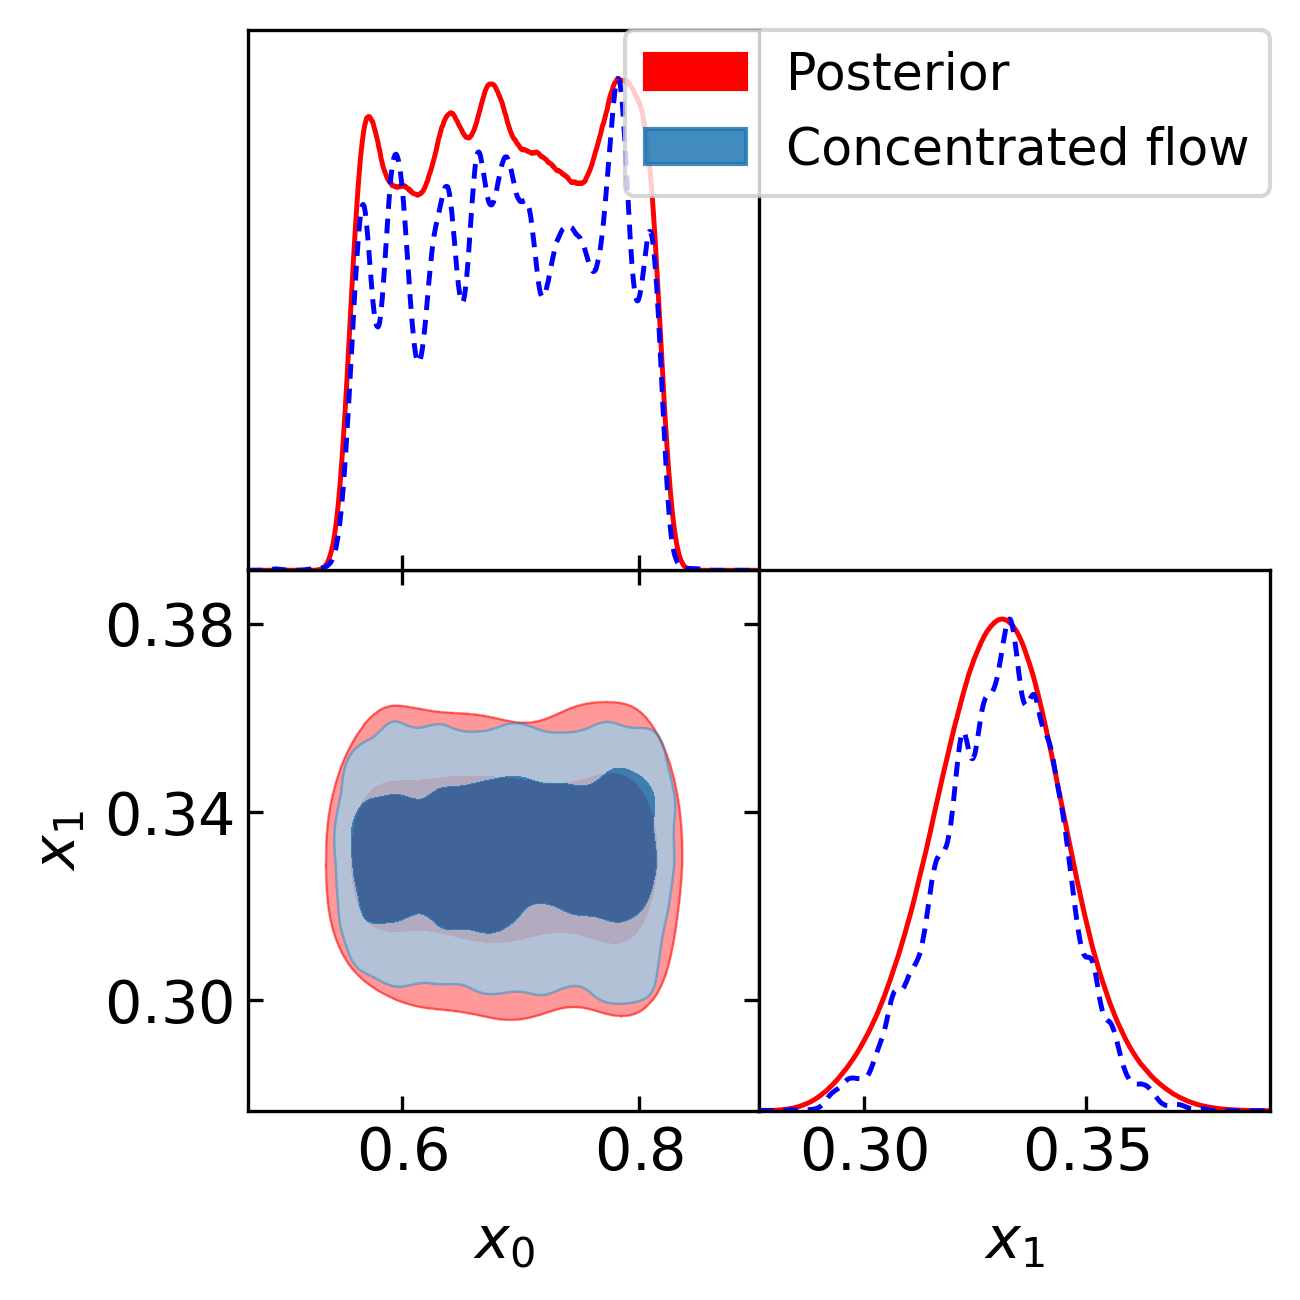

ensure that the concentrated flow is contained within the posterior


Training NF: 100%|██████████| 15/15 [01:13<00:00,  4.91s/it]


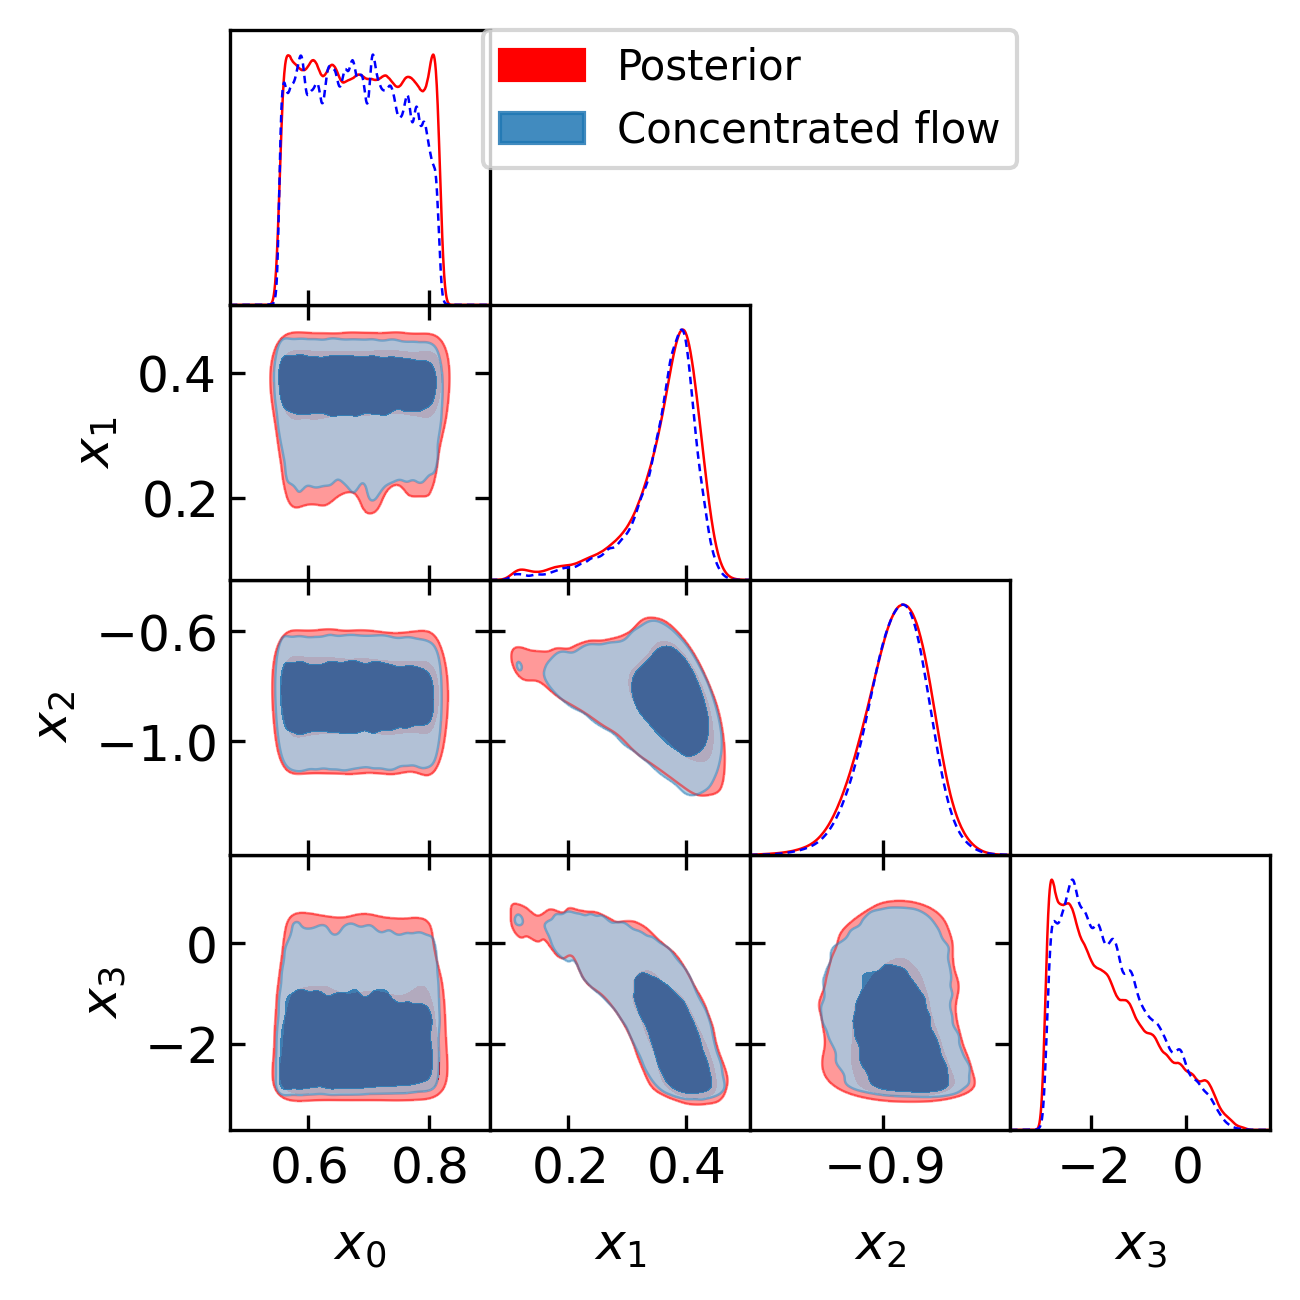

ensure that the concentrated flow is contained within the posterior


In [4]:
# train normalising flows
lcdm_dd.train_model(verbose=True, temp=0.8)
cpl_dd.train_model(verbose=True, temp=0.8)

In [5]:
# adjust temperatures if needed (uncomment to tighten the flow)
# lcdm_dd.set_temp(temp=0.7, verbose=True)
# cpl_dd.set_temp(temp=0.7, verbose=True)

In [6]:
# MCEvidence Bayes factor (DD)
mce_dd = lcdm_dd.get_MCE_bayes_factor(cpl_dd)

INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../nautilus/lcdm_DD_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=0.144
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=2
INFO:MCEvidence.py.setup():164      Loading chain from ../nautilus/lcdm_DD_BE
INFO:MCEvidence.py.load_from_file():666       loading files: ../nautilus/lcdm_DD_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD_BE.1.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD_BE.5.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD_BE.4.txt
INFO:MCEvidence.py

RUNNING MCMC EVIDENCE FOR COBAYA
ln(B)[k=1] = -817.8198285152376


RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../nautilus/cpl_DD_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=1.872
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=4
INFO:MCEvidence.py.setup():164      Loading chain from ../nautilus/cpl_DD_BE
INFO:MCEvidence.py.load_from_file():666       loading files: ../nautilus/cpl_DD_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD_BE.5.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD_BE.1.txt
INFO:MCEvidence.py.removeB

ln(B)[k=1] = -818.7928926660303




In [7]:
# LHME Bayes factor and per-model evidence (DD, block_num=16)
harm_dd = lcdm_dd.get_LHME_bayes_factor(cpl_dd)

print("LCDM (DD) block_num=16")
lcdm_dd.check_evidence()
print("CPL (DD) block_num=16")
cpl_dd.check_evidence()

LCDM (DD) block_num=16
=== Checking Reliability of Evidence ===
ln kurtosis: 0.7200 (>>1 implies evidence may be unreliable)
CPL (DD) block_num=16
=== Checking Reliability of Evidence ===
ln kurtosis: 1.1831 (>>1 implies evidence may be unreliable)


In [8]:
# block_num variants for harmonic (DD) — fully reinitialise and retrain
harm_dd_blocks = {16: harm_dd}
hmZ_lcdm_dd = {16: lcdm_dd.get_hm_evidence()}
hmZ_cpl_dd = {16: cpl_dd.get_hm_evidence()}

for bn in [8, 32]:
    a = make_and_train(lcdm_root_dd, lcdm_params_dd, burnin=0.3, block_num=bn)
    b = make_and_train(cpl_root_dd, cpl_params_dd, burnin=0.3, block_num=bn)
    harm_dd_blocks[bn] = a.get_LHME_bayes_factor(b)
    hmZ_lcdm_dd[bn] = a.get_hm_evidence()
    hmZ_cpl_dd[bn] = b.get_hm_evidence()
    print(f"LCDM (DD) block_num={bn}")
    a.check_evidence()
    print(f"CPL (DD) block_num={bn}")
    b.check_evidence()

LCDM (DD) block_num=8
=== Checking Reliability of Evidence ===
ln kurtosis: 0.6524 (>>1 implies evidence may be unreliable)
CPL (DD) block_num=8
=== Checking Reliability of Evidence ===
ln kurtosis: 0.6732 (>>1 implies evidence may be unreliable)
LCDM (DD) block_num=32
=== Checking Reliability of Evidence ===
ln kurtosis: nan (>>1 implies evidence may be unreliable)
CPL (DD) block_num=32
=== Checking Reliability of Evidence ===
ln kurtosis: 1.0006 (>>1 implies evidence may be unreliable)


INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode


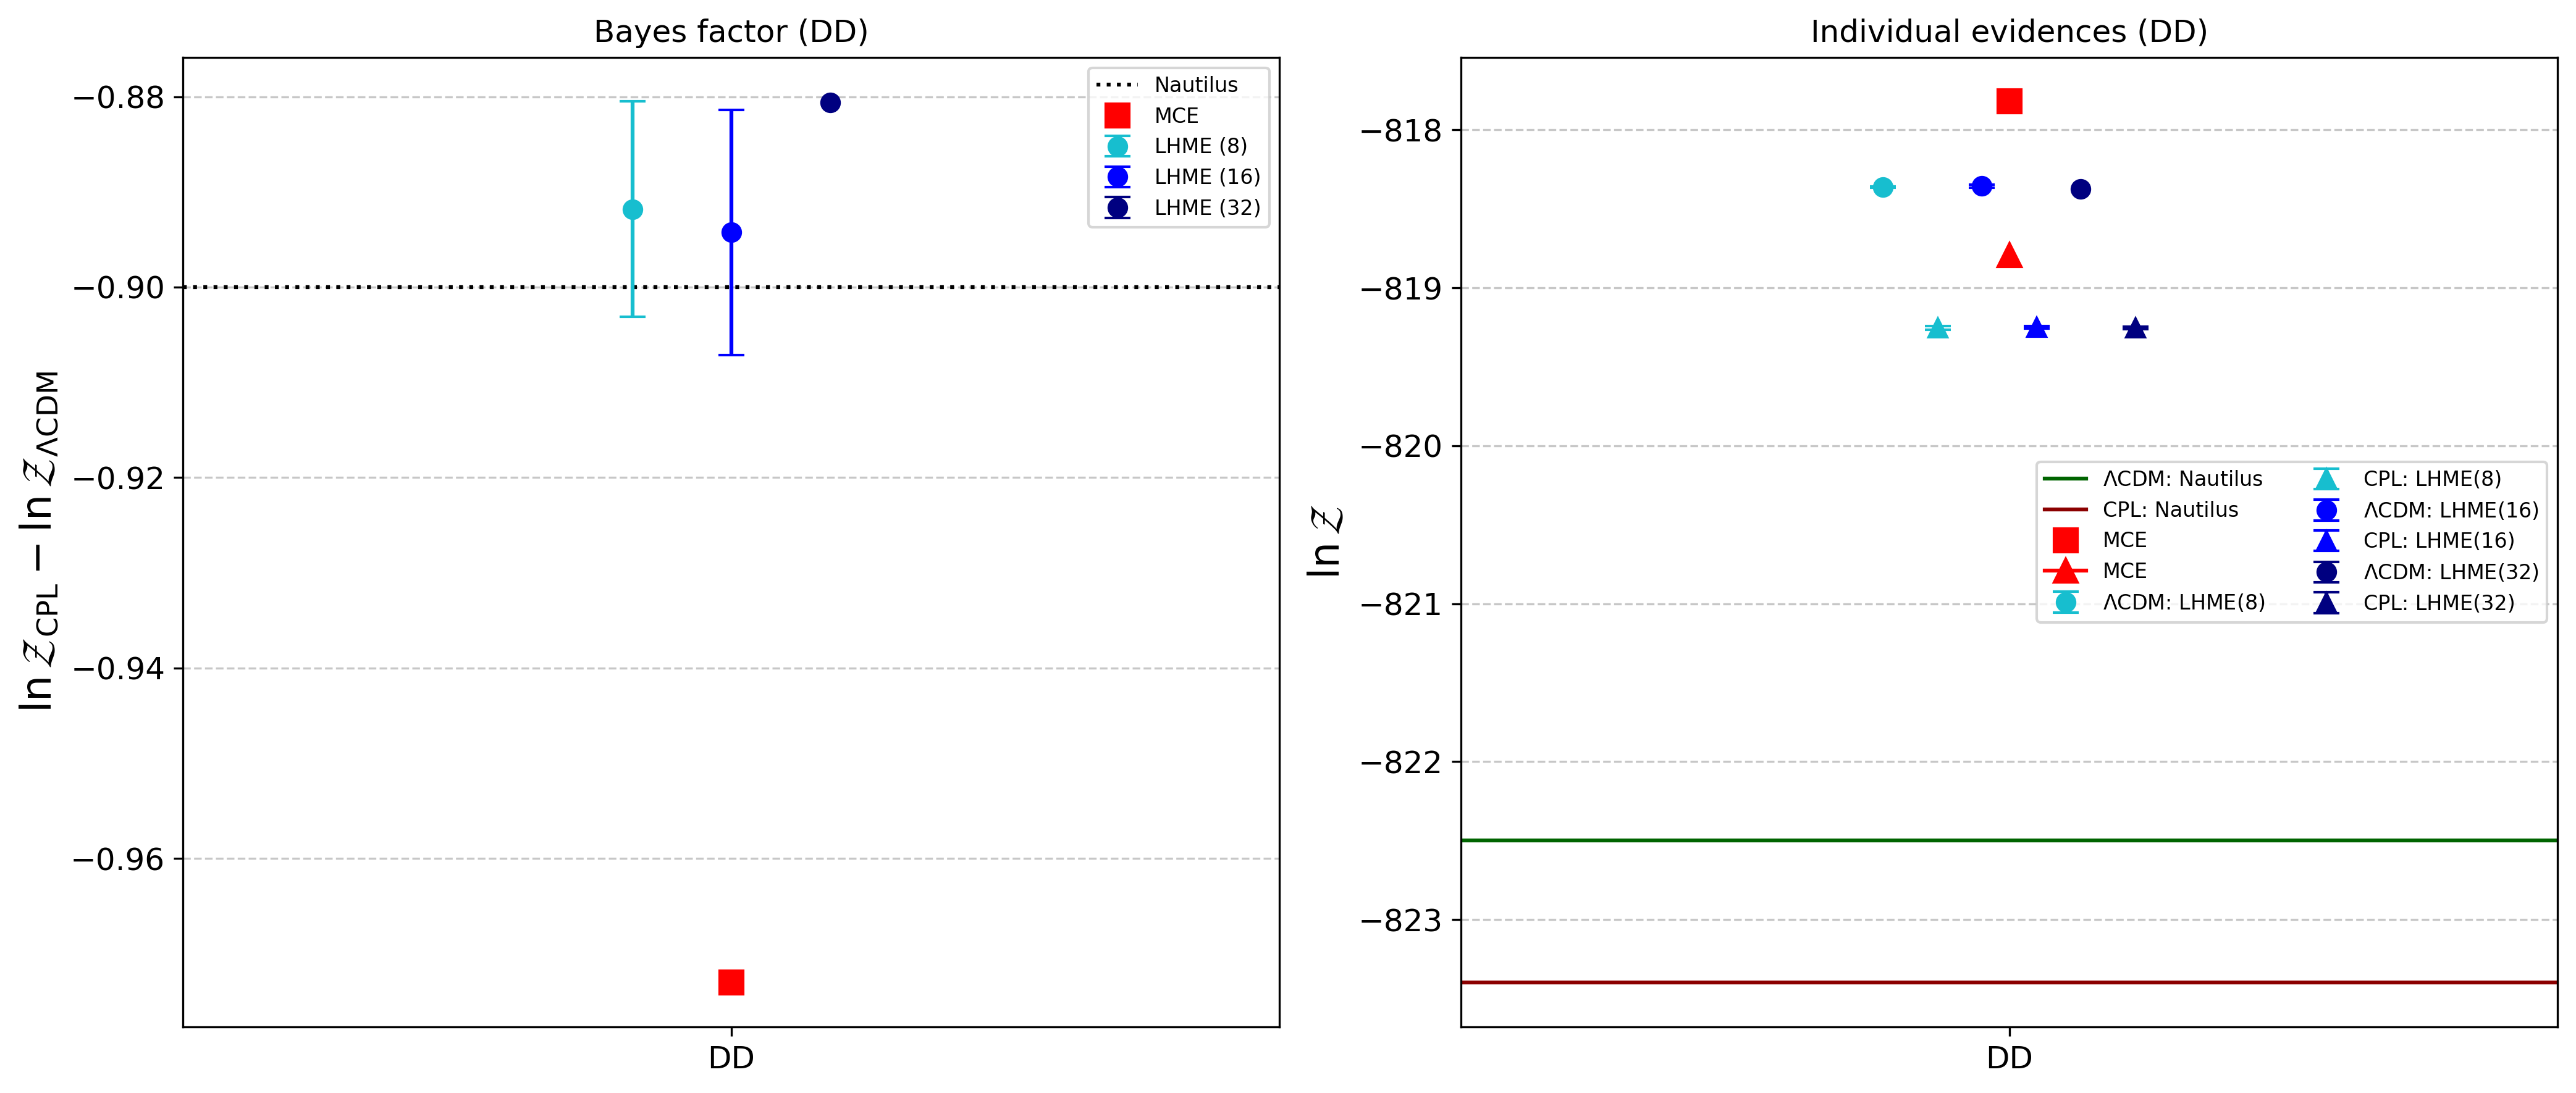

In [20]:
# plotting Bayes factor and individual evidences (DD)
x_labels = ["DD"]
x_pos = np.array([0])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Bayes factor ---
ax = axes[0]
ax.axhline(NAUT_DD["bf"], color="black", linestyle=":", label="Nautilus")
ax.plot(x_pos, [mce_dd], "s", color="red", label="MCE", markersize=9)
for bn in block_nums:
    mean = harm_dd_blocks[bn][0]
    lower = harm_dd_blocks[bn][1]
    upper = harm_dd_blocks[bn][2]
    ax.errorbar(
        x_pos + block_offsets[bn],
        [mean],
        yerr=[[lower], [upper]],
        fmt="o",
        color=block_colors[bn],
        capsize=5,
        label=f"LHME ({bn})",
        markersize=7,
    )
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel(r"$\ln\mathcal{Z}_\mathrm{CPL}-\ln\mathcal{Z}_{\Lambda\mathrm{CDM}}$")
ax.set_title("Bayes factor (DD)")
ax.set_xlim(-1, 1)
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# --- Individual evidences ---
ax = axes[1]
ax.axhline(
    NAUT_DD["lcdm"], color="darkgreen", linestyle="-", label=r"$\Lambda$CDM: Nautilus"
)
ax.axhline(NAUT_DD["cpl"], color="darkred", linestyle="-", label=r"CPL: Nautilus")
for bn in block_nums:
    lcdm_v = to_lnZ(hmZ_lcdm_dd[bn])
    cpl_v = to_lnZ(hmZ_cpl_dd[bn])
    ax.errorbar(
        x_pos + block_offsets[bn] - 0.05,
        [lcdm_v[0]],
        yerr=[[lcdm_v[1]], [lcdm_v[2]]],
        fmt="o",
        color=block_colors[bn],
        capsize=5,
        label=rf"$\Lambda$CDM: LHME({bn})",
        markersize=7,
    )
    ax.errorbar(
        x_pos + block_offsets[bn] + 0.05,
        [cpl_v[0]],
        yerr=[[cpl_v[1]], [cpl_v[2]]],
        fmt="^",
        color=block_colors[bn],
        capsize=5,
        label=rf"CPL: LHME({bn})",
        markersize=7,
    )
ax.plot(x_pos, -817.8198285152376, "s", color="red", label="MCE", markersize=9)  # LCDM
ax.plot(
    x_pos, -818.7928926660303, color="red", marker="^", label="MCE", markersize=9
)  # CPL
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel(r"$\ln\mathcal{Z}$")
ax.set_title("Individual evidences (DD)")
ax.set_xlim(-1, 1)
ax.legend(fontsize=8, ncol=2)
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("figures/nautilus_DD_evidence.pdf", bbox_inches="tight")
plt.show()

# DD+BAO

In [10]:
## parameters (same as DD)
lcdm_params_ddbao = ["h", "Omega_m"]
cpl_params_ddbao = ["h", "Omega_m", "w0_fld", "wa_fld"]

lcdm_root_ddbao = "../nautilus/lcdm_DD+BAO"
cpl_root_ddbao = "../nautilus/cpl_DD+BAO"

lcdm_ddbao = cosmo_model(lcdm_root_ddbao, block_num=16, nchains=8, burnin=0.3)
cpl_ddbao = cosmo_model(cpl_root_ddbao, block_num=16, nchains=8, burnin=0.3)

lcdm_ddbao.set_sampled_params(lcdm_params_ddbao)
cpl_ddbao.set_sampled_params(cpl_params_ddbao)

print(f"LCDM (DD+BAO) R-1 = {lcdm_ddbao.get_gelman_rubin()}")
print(f"CPL  (DD+BAO) R-1 = {cpl_ddbao.get_gelman_rubin()}")

LCDM (DD+BAO) R-1 = 0.003484327223443179
CPL  (DD+BAO) R-1 = 0.0052640820915312095


Training NF: 100%|██████████| 15/15 [00:05<00:00,  2.74it/s]


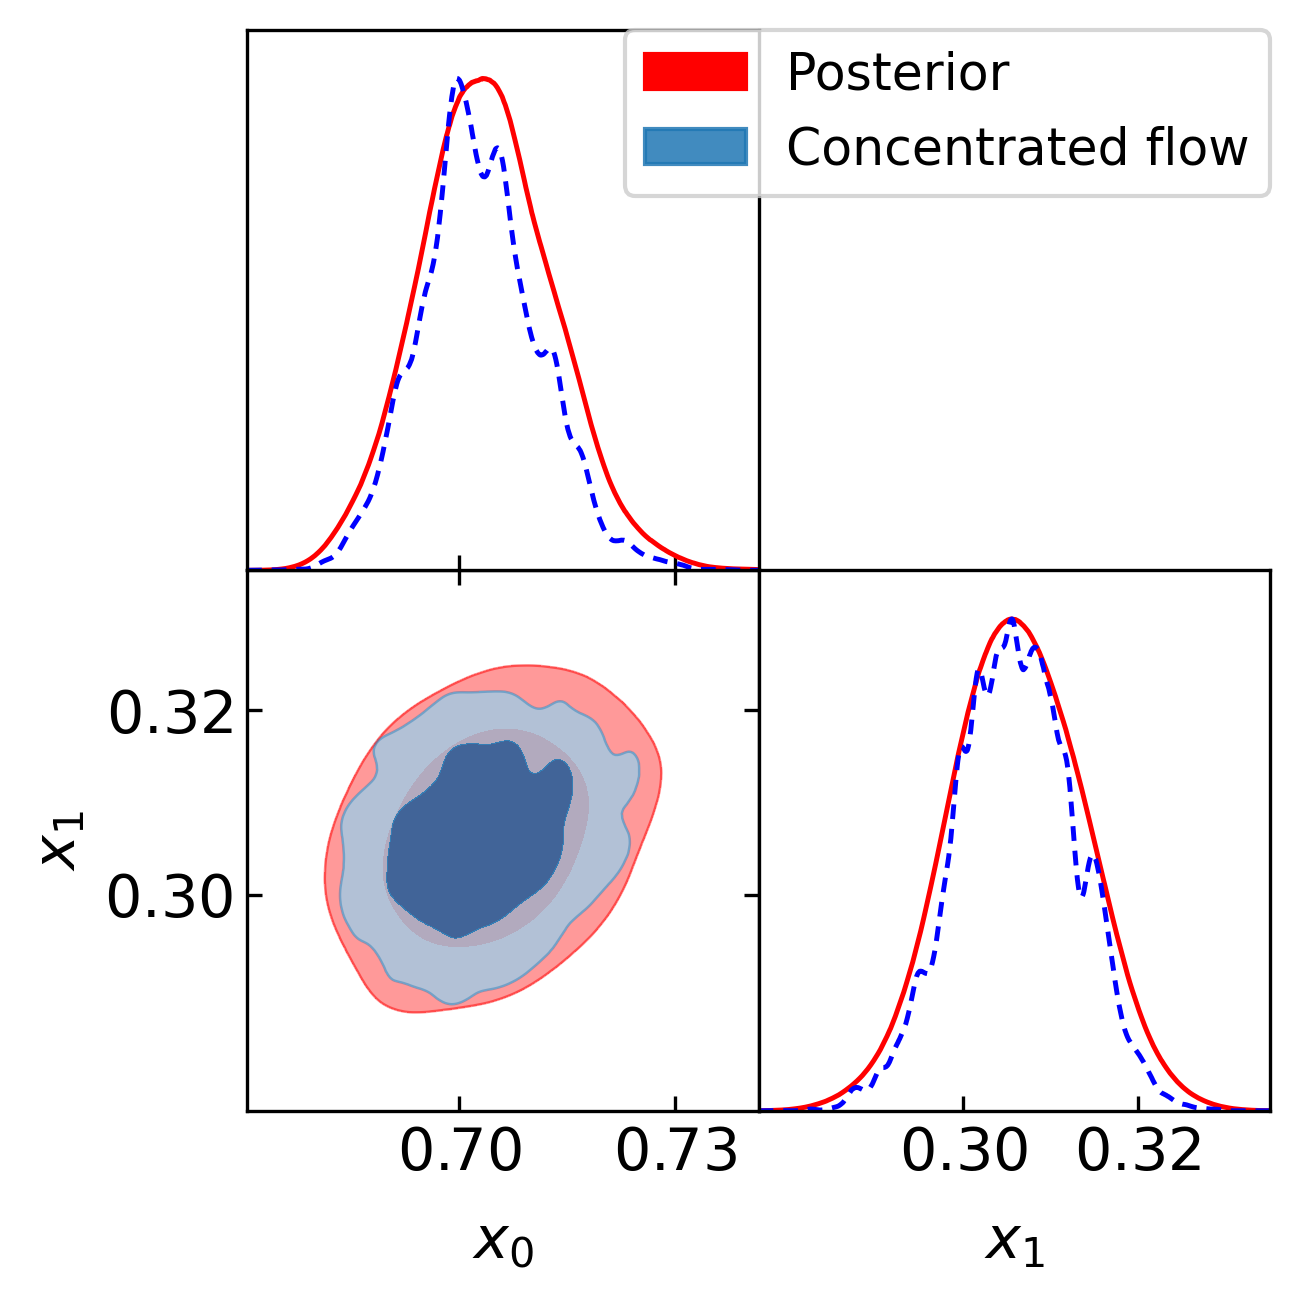

ensure that the concentrated flow is contained within the posterior


Training NF: 100%|██████████| 15/15 [00:26<00:00,  1.79s/it]


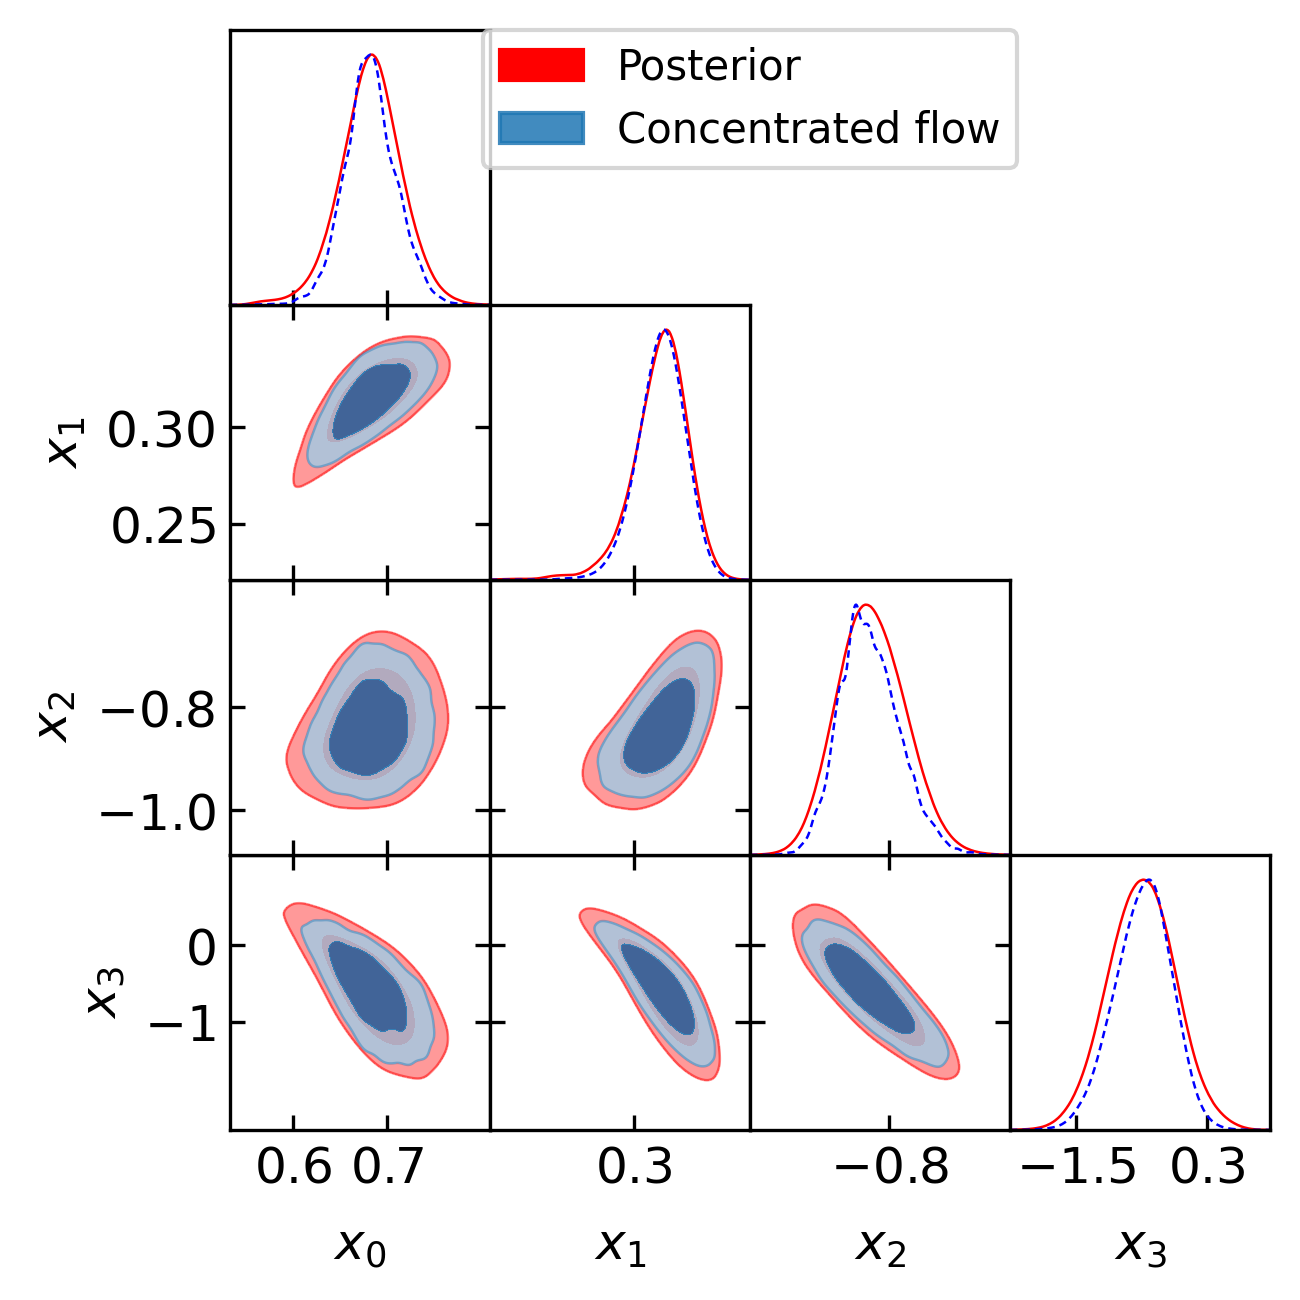

ensure that the concentrated flow is contained within the posterior


In [11]:
# train normalising flows
lcdm_ddbao.train_model(verbose=True, temp=0.8)
cpl_ddbao.train_model(verbose=True, temp=0.8)

In [12]:
# adjust temperatures if needed
# lcdm_ddbao.set_temp(temp=0.7, verbose=True)
# cpl_ddbao.set_temp(temp=0.7, verbose=True)

In [13]:
# MCEvidence Bayes factor (DD+BAO)
mce_ddbao = lcdm_ddbao.get_MCE_bayes_factor(cpl_ddbao)

INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../nautilus/lcdm_DD+BAO_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=0.144
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=2
INFO:MCEvidence.py.setup():164      Loading chain from ../nautilus/lcdm_DD+BAO_BE
INFO:MCEvidence.py.load_from_file():666       loading files: ../nautilus/lcdm_DD+BAO_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD+BAO_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD+BAO_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD+BAO_BE.1.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD+BAO_BE.5.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/lcdm_DD

RUNNING MCMC EVIDENCE FOR COBAYA
ln(B)[k=1] = -828.0304677685286


RUNNING MCMC EVIDENCE FOR COBAYA


INFO:MCEvidence.py.params_info():1377     getting params info from COSMOMC file ../nautilus/cpl_DD+BAO_BE.ranges
INFO:MCEvidence.py.get_prior_volume():1486     getting prior volume using cosmomc *.ranges or montepython log.param outputs
INFO:MCEvidence.py.get_prior_volume():1489     prior_volume=1.872
INFO:MCEvidence.py.get_prior_volume():1490     Number of params to use: ndim=4
INFO:MCEvidence.py.setup():164      Loading chain from ../nautilus/cpl_DD+BAO_BE
INFO:MCEvidence.py.load_from_file():666       loading files: ../nautilus/cpl_DD+BAO_BE.?.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD+BAO_BE.2.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD+BAO_BE.3.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD+BAO_BE.1.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD+BAO_BE.4.txt
INFO:MCEvidence.py.read_list_to_array():635      loading: ../nautilus/cpl_DD+BAO_BE.

ln(B)[k=1] = -829.4735184800795




In [14]:
# LHME Bayes factor (DD+BAO, block_num=16)
harm_ddbao = lcdm_ddbao.get_LHME_bayes_factor(cpl_ddbao)

print("LCDM (DD+BAO) block_num=16")
lcdm_ddbao.check_evidence()
print("CPL (DD+BAO) block_num=16")
cpl_ddbao.check_evidence()

LCDM (DD+BAO) block_num=16
=== Checking Reliability of Evidence ===
ln kurtosis: 0.7128 (>>1 implies evidence may be unreliable)
CPL (DD+BAO) block_num=16
=== Checking Reliability of Evidence ===
ln kurtosis: 0.7792 (>>1 implies evidence may be unreliable)


In [15]:
# block_num variants for harmonic (DD+BAO)
harm_ddbao_blocks = {16: harm_ddbao}
hmZ_lcdm_ddbao = {16: lcdm_ddbao.get_hm_evidence()}
hmZ_cpl_ddbao = {16: cpl_ddbao.get_hm_evidence()}

for bn in [8, 32]:
    a = make_and_train(lcdm_root_ddbao, lcdm_params_ddbao, burnin=0.3, block_num=bn)
    b = make_and_train(cpl_root_ddbao, cpl_params_ddbao, burnin=0.3, block_num=bn)
    harm_ddbao_blocks[bn] = a.get_LHME_bayes_factor(b)
    hmZ_lcdm_ddbao[bn] = a.get_hm_evidence()
    hmZ_cpl_ddbao[bn] = b.get_hm_evidence()
    print(f"LCDM (DD+BAO) block_num={bn}")
    a.check_evidence()
    print(f"CPL (DD+BAO) block_num={bn}")
    b.check_evidence()

LCDM (DD+BAO) block_num=8
=== Checking Reliability of Evidence ===
ln kurtosis: 0.6910 (>>1 implies evidence may be unreliable)
CPL (DD+BAO) block_num=8
=== Checking Reliability of Evidence ===
ln kurtosis: 0.2033 (>>1 implies evidence may be unreliable)
LCDM (DD+BAO) block_num=32
=== Checking Reliability of Evidence ===
ln kurtosis: 0.7571 (>>1 implies evidence may be unreliable)
CPL (DD+BAO) block_num=32
=== Checking Reliability of Evidence ===
ln kurtosis: 1.1487 (>>1 implies evidence may be unreliable)


INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode
INFO:_mathtext.py._get_glyph():642      Substituting symbol Z from STIXNonUnicode


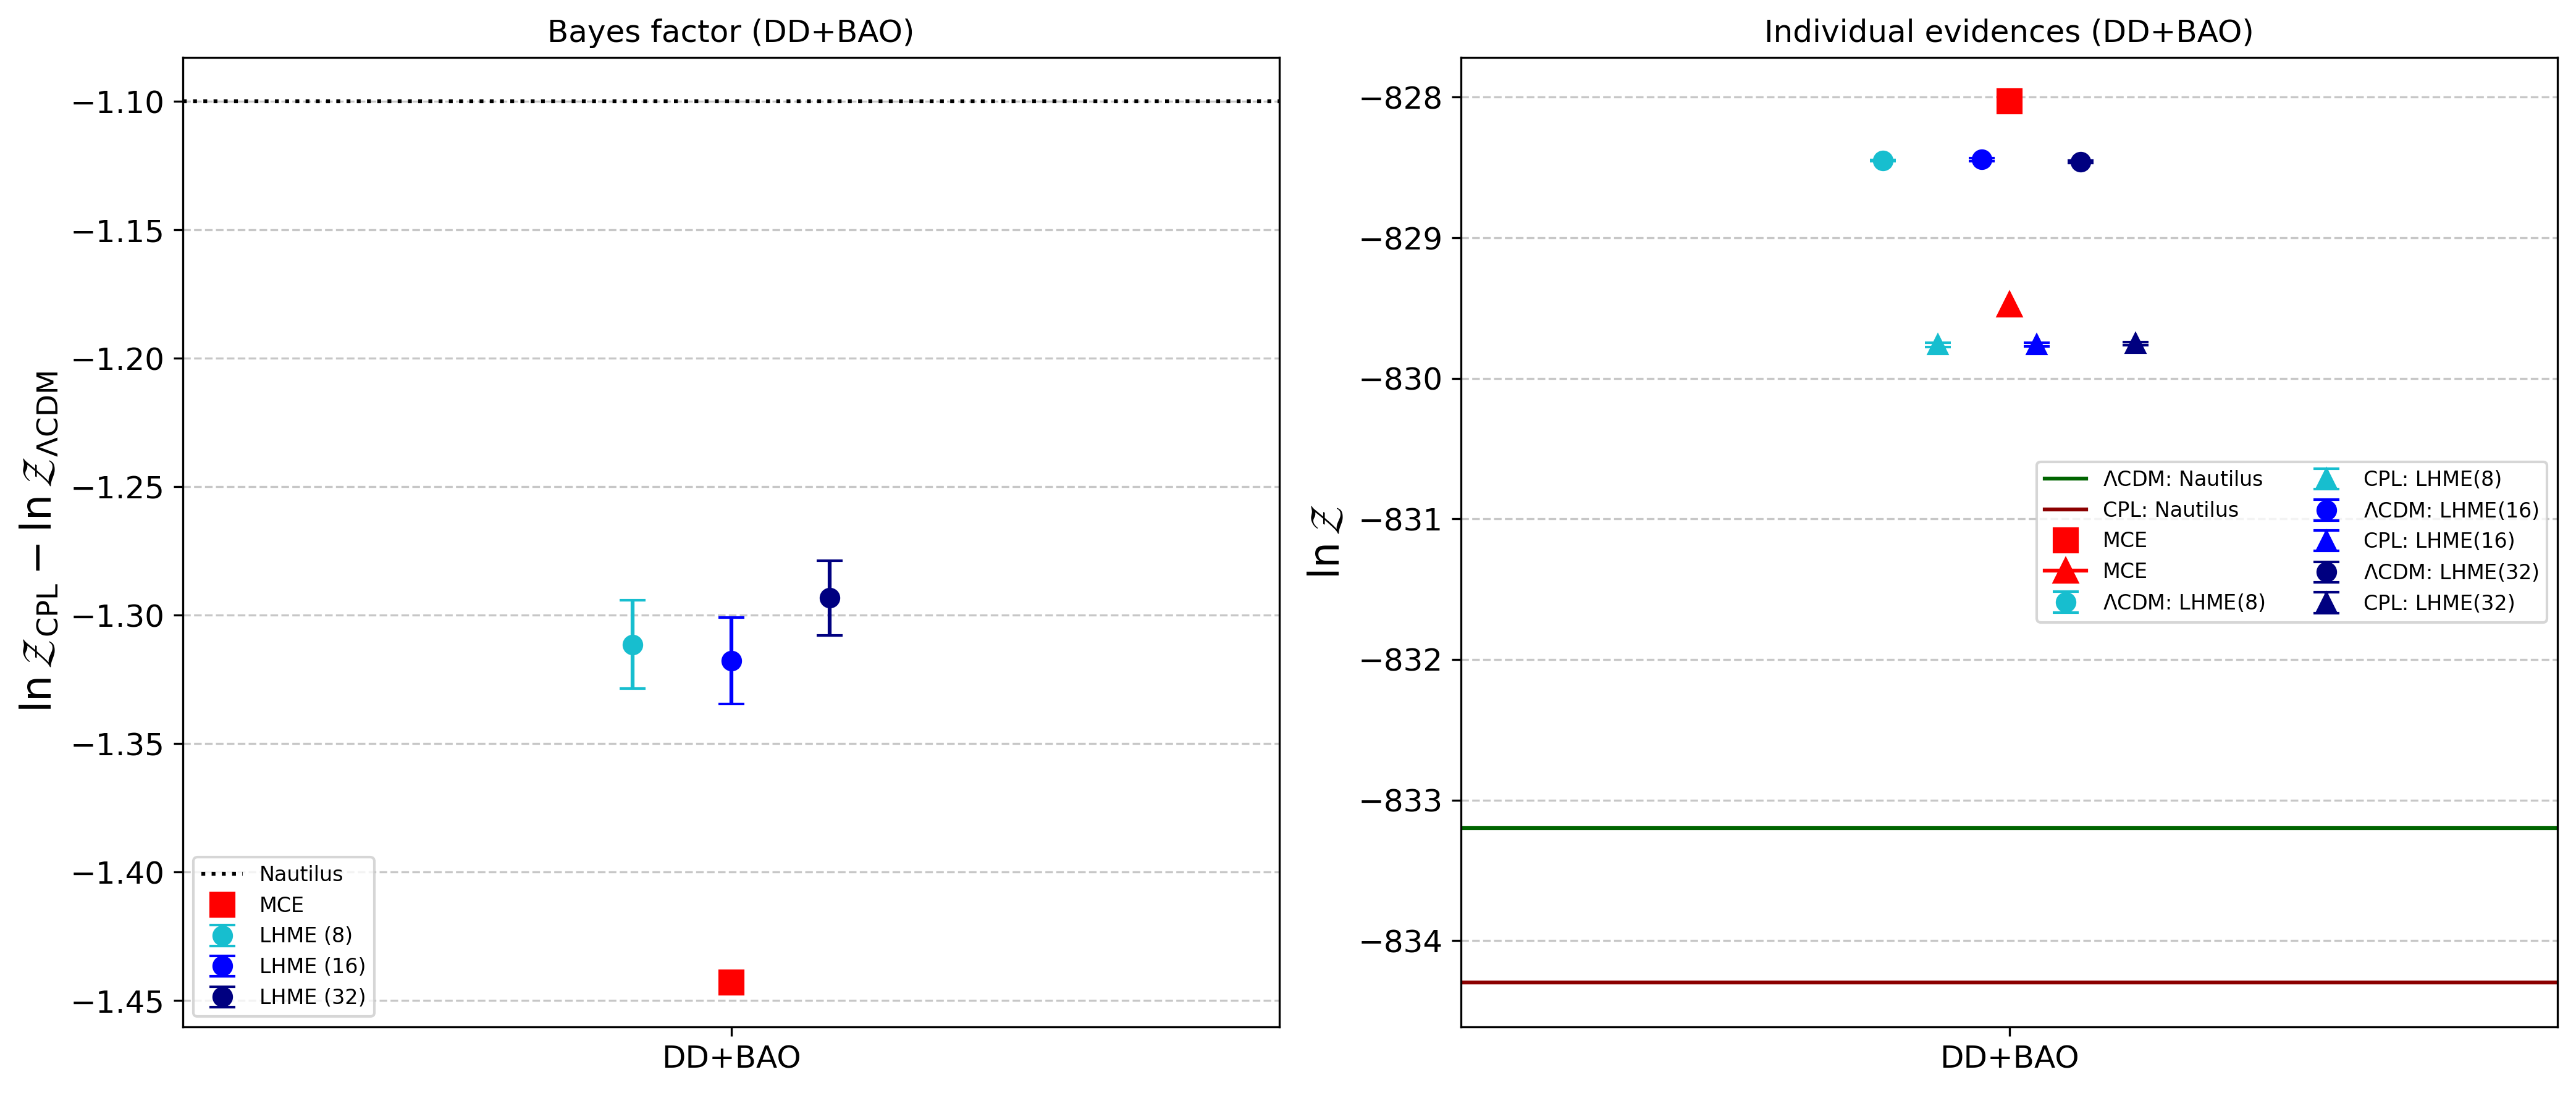

In [19]:
# plotting Bayes factor and individual evidences (DD+BAO)
x_labels = ["DD+BAO"]
x_pos = np.array([0])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Bayes factor ---
ax = axes[0]
ax.axhline(NAUT_DDBAO["bf"], color="black", linestyle=":", label="Nautilus")
ax.plot(x_pos, [mce_ddbao], "s", color="red", label="MCE", markersize=9)
for bn in block_nums:
    mean = harm_ddbao_blocks[bn][0]
    lower = harm_ddbao_blocks[bn][1]
    upper = harm_ddbao_blocks[bn][2]
    ax.errorbar(
        x_pos + block_offsets[bn],
        [mean],
        yerr=[[lower], [upper]],
        fmt="o",
        color=block_colors[bn],
        capsize=5,
        label=f"LHME ({bn})",
        markersize=7,
    )
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel(r"$\ln\mathcal{Z}_\mathrm{CPL}-\ln\mathcal{Z}_{\Lambda\mathrm{CDM}}$")
ax.set_title("Bayes factor (DD+BAO)")
ax.set_xlim(-1, 1)
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# --- Individual evidences ---
ax = axes[1]
ax.axhline(
    NAUT_DDBAO["lcdm"],
    color="darkgreen",
    linestyle="-",
    label=r"$\Lambda$CDM: Nautilus",
)
ax.axhline(NAUT_DDBAO["cpl"], color="darkred", linestyle="-", label=r"CPL: Nautilus")
for bn in block_nums:
    lcdm_v = to_lnZ(hmZ_lcdm_ddbao[bn])
    cpl_v = to_lnZ(hmZ_cpl_ddbao[bn])
    ax.errorbar(
        x_pos + block_offsets[bn] - 0.05,
        [lcdm_v[0]],
        yerr=[[lcdm_v[1]], [lcdm_v[2]]],
        fmt="o",
        color=block_colors[bn],
        capsize=5,
        label=rf"$\Lambda$CDM: LHME({bn})",
        markersize=7,
    )
    ax.errorbar(
        x_pos + block_offsets[bn] + 0.05,
        [cpl_v[0]],
        yerr=[[cpl_v[1]], [cpl_v[2]]],
        fmt="^",
        color=block_colors[bn],
        capsize=5,
        label=rf"CPL: LHME({bn})",
        markersize=7,
    )
ax.plot(x_pos, -828.0304677685286, "s", color="red", label="MCE", markersize=9)  # LCDM
ax.plot(
    x_pos, -829.4735184800795, color="red", marker="^", label="MCE", markersize=9
)  # CPL
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel(r"$\ln\mathcal{Z}$")
ax.set_title("Individual evidences (DD+BAO)")
ax.set_xlim(-1, 1)
ax.legend(fontsize=8, ncol=2)
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("figures/nautilus_DD+BAO_evidence.pdf", bbox_inches="tight")
plt.show()

# Numerical summary

Printing all evidence and Bayes-factor values produced above so it is clear which number came from which estimator.

In [17]:
def fmt_lnZ(hm_res):
    lnZ, lo, up = to_lnZ(hm_res)
    return f"{lnZ:+.3f} (+{up:.3f} / -{lo:.3f})"


def fmt_bf(bf_tuple):
    mean, lo, up = bf_tuple
    return f"{mean:+.3f} (+{up:.3f} / -{lo:.3f})"


def print_dataset(name, naut, mce_bf, harm_blocks, hmZ_lcdm, hmZ_cpl):
    print(f"=== {name} ===")
    print("  ln Z (LCDM):")
    print(f"    Nautilus     : {naut['lcdm']:+.3f}")
    for bn in block_nums:
        print(f"    LHME bn={bn:>2}  : {fmt_lnZ(hmZ_lcdm[bn])}")
    print("  ln Z (CPL):")
    print(f"    Nautilus     : {naut['cpl']:+.3f}")
    for bn in block_nums:
        print(f"    LHME bn={bn:>2}  : {fmt_lnZ(hmZ_cpl[bn])}")
    print("  Bayes factor  ln Z_CPL - ln Z_LCDM:")
    print(f"    Nautilus     : {naut['bf']:+.3f}")
    print(f"    MCEvidence   : {mce_bf:+.3f}")
    for bn in block_nums:
        print(f"    LHME bn={bn:>2}  : {fmt_bf(harm_blocks[bn])}")
    print()


print_dataset("DD", NAUT_DD, mce_dd, harm_dd_blocks, hmZ_lcdm_dd, hmZ_cpl_dd)
print_dataset(
    "DD+BAO", NAUT_DDBAO, mce_ddbao, harm_ddbao_blocks, hmZ_lcdm_ddbao, hmZ_cpl_ddbao
)

=== DD ===
  ln Z (LCDM):
    Nautilus     : -822.500
    LHME bn= 8  : -818.362 (+0.005 / -0.004)
    LHME bn=16  : -818.355 (+0.010 / -0.010)
    LHME bn=32  : -818.373 (+inf / -nan)
  ln Z (CPL):
    Nautilus     : -823.400
    LHME bn= 8  : -819.254 (+0.010 / -0.010)
    LHME bn=16  : -819.250 (+0.008 / -0.008)
    LHME bn=32  : -819.253 (+0.009 / -0.009)
  Bayes factor  ln Z_CPL - ln Z_LCDM:
    Nautilus     : -0.900
    MCEvidence   : -0.973
    LHME bn= 8  : -0.892 (+0.011 / -0.011)
    LHME bn=16  : -0.894 (+0.013 / -0.013)
    LHME bn=32  : -0.881 (+nan / -inf)

=== DD+BAO ===
  ln Z (LCDM):
    Nautilus     : -833.200
    LHME bn= 8  : -828.450 (+0.005 / -0.005)
    LHME bn=16  : -828.443 (+0.010 / -0.010)
    LHME bn=32  : -828.459 (+0.008 / -0.008)
  ln Z (CPL):
    Nautilus     : -834.300
    LHME bn= 8  : -829.761 (+0.017 / -0.016)
    LHME bn=16  : -829.761 (+0.014 / -0.014)
    LHME bn=32  : -829.753 (+0.012 / -0.012)
  Bayes factor  ln Z_CPL - ln Z_LCDM:
    Nautilus  